In [ ]:
import pandas as pd
import numpy as np
import os
import glob


def custom_sample_with_slope(
    df,
    samples,
    slope_threshold=0.01,
    apply_slope_limit=False,
    min_consecutive=3
):
    df.columns = df.columns.str.strip().str.capitalize()

    required = {"Mass", "Radius", "K2", "Type"}
    if not required.issubset(df.columns):
        raise ValueError(f"Missing columns: {required - set(df.columns)}")

    df_sorted = df.sort_values("Mass").reset_index(drop=True)

    if apply_slope_limit:
        slopes = np.gradient(df_sorted["Mass"], df_sorted["Radius"])
        flat = np.abs(slopes) > slope_threshold

        count = 0
        cutoff_idx = None
        for i, f in enumerate(flat):
            if f:
                count += 1
                if count >= min_consecutive:
                    cutoff_idx = i - min_consecutive + 1
                    break
            else:
                count = 0

        if cutoff_idx is not None:
            df_sorted = df_sorted.iloc[cutoff_idx:].reset_index(drop=True)

    # Even sampling in mass
    min_mass = df_sorted["Mass"].min()
    max_mass = df_sorted["Mass"].max()
    target_masses = np.linspace(min_mass, max_mass, samples)

    chosen = []
    for tm in target_masses:
        idx = (df_sorted["Mass"] - tm).abs().idxmin()
        chosen.append(df_sorted.loc[idx])

    # Always include maximum mass point
    chosen.append(df_sorted.loc[df_sorted["Mass"].idxmax()])
    data =pd.DataFrame(chosen).drop_duplicates().reset_index(drop=True)
    data["Type"] = data["Type"].astype(int)
    return data

# File patterns
file_patterns = [
    r"C:\Users\vasil\Desktop\TOV DATA\GIT_TOV_EQUATION\Quark Stars\TOV_results_Qark_Stars_tidal\TOV_results_CFL*.csv",
    r"C:\Users\vasil\Desktop\TOV DATA\GIT_TOV_EQUATION\polytropic_stars\polytropic_main\TOV_results_tidal_HLPS2\EOS_*.csv",
    r"C:\Users\vasil\Desktop\TOV DATA\GIT_TOV_EQUATION\polytropic_stars\polytropic_main\TOV_results_tidal_HLPS3\EOS_*.csv"
]

sampled_data = []

for pattern in file_patterns:
    files = glob.glob(pattern)
    print(f"📁 Found {len(files)} files for pattern: {pattern}")
    for file in files:
        df = pd.read_csv(file)
        if 'CFL' in file:
            sample = custom_sample_with_slope(df, samples=5, slope_threshold=1.5*1e-2, apply_slope_limit=False)
        else:
            sample = custom_sample_with_slope(df, samples=5, slope_threshold=1.5*1e-2, apply_slope_limit=True)
        sampled_data.append(sample)

# Combine all samples
final_sample = pd.concat(sampled_data, ignore_index=True)

# Keep only Mass, Radius, K2
final_sample = final_sample[["Mass", "Radius", "K2", "Type"]]

# Save
output_path = "custom_sample_mass_radius_k2_5.csv"
final_sample.to_csv(output_path, index=False)

print(f"✅ Saved sampled data to {output_path}")
print(final_sample.head())


📁 Found 2029 files for pattern: C:\Users\vasil\Desktop\TOV DATA\GIT_TOV_EQUATION\Quark Stars\TOV_results_Qark_Stars_tidal\TOV_results_CFL*.csv
📁 Found 1024 files for pattern: C:\Users\vasil\Desktop\TOV DATA\GIT_TOV_EQUATION\polytropic_stars\polytropic_main\TOV_results_tidal_HLPS2\EOS_*.csv
📁 Found 1024 files for pattern: C:\Users\vasil\Desktop\TOV DATA\GIT_TOV_EQUATION\polytropic_stars\polytropic_main\TOV_results_tidal_HLPS3\EOS_*.csv
✅ Saved sampled data to custom_sample_mass_radius_k2_5.csv
       Mass  Radius        K2  Type
0  0.023955    2.99  0.724897     1
1  0.517441    8.15  0.492021     1
2  1.000688    9.93  0.360845     1
3  1.493551   10.98  0.251277     1
4  1.984482   10.80  0.105644     1


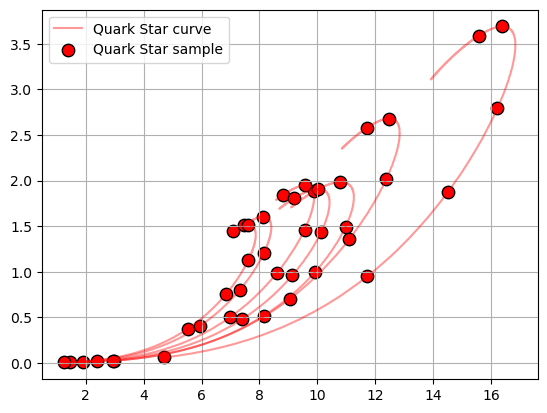

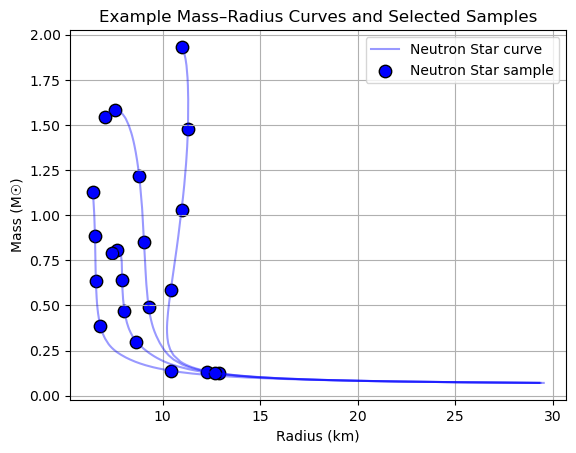

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob
import os

def custom_sample_with_slope(df, samples, slope_threshold=0.01, apply_slope_limit=False, min_consecutive=3):
    df.columns = df.columns.str.strip().str.capitalize()
    if not all(col in df.columns for col in ["Mass", "Radius", "K2"]):
        raise ValueError("Missing one of required columns: Mass, Radius, K2")
    
    df_sorted = df.sort_values("Mass").reset_index(drop=True)
    
    if apply_slope_limit:
        slopes = np.gradient(df_sorted["Mass"], df_sorted["Radius"])
        
        # Find consecutive flat slope indices
        flat = np.abs(slopes) > slope_threshold
        count = 0
        cutoff_idx = None
        for i, f in enumerate(flat):
            if f:
                count += 1
                if count >= min_consecutive:
                    cutoff_idx = i - min_consecutive + 1
                    break
            else:
                count = 0
        
        # If found, keep only before the plateau starts (drop low-mass flat region)
        if cutoff_idx is not None:
            df_sorted = df_sorted.iloc[cutoff_idx:].reset_index(drop=True)

    # Sampling evenly in mass
    min_mass = df_sorted["Mass"].min()
    max_mass = df_sorted["Mass"].max()
    target_masses = np.linspace(min_mass, max_mass, samples)
    
    chosen_rows = pd.DataFrame()
    for tm in target_masses:
        idx = (df_sorted["Mass"] - tm).abs().idxmin()
        chosen_rows = pd.concat([chosen_rows, df_sorted.loc[[idx]]])
    
    # Always include max mass point
    max_mass_row = df_sorted.loc[df_sorted["Mass"].idxmax()]
    if not (chosen_rows["Mass"] == max_mass_row["Mass"]).any():
        chosen_rows = pd.concat([chosen_rows, pd.DataFrame([max_mass_row])])
    
    # Ensure at least one smaller mass + smaller radius
    smaller_candidates = df_sorted[
        (abs(df_sorted["Mass"] - max_mass_row["Mass"]) < 1e-1) &
        (df_sorted["Radius"] < max_mass_row["Radius"])
    ]
    if not smaller_candidates.empty:
        chosen_rows = pd.concat([chosen_rows, smaller_candidates.head(1)])
    
    return chosen_rows.drop_duplicates().reset_index(drop=True)

# File patterns
quark_pattern = r"C:\Users\vasil\Desktop\TOV DATA\GIT_TOV_EQUATION\Quark Stars\TOV_results_Qark_Stars_tidal\TOV_results_CFL*.csv"
neutron_pattern = r"C:\Users\vasil\Desktop\TOV DATA\GIT_TOV_EQUATION\polytropic_stars\polytropic_main\TOV_results_tidal_HLPS2\EOS_*.csv"

# Pick first 2 files from each
quark_files = glob.glob(quark_pattern)[::300]
neutron_files = glob.glob(neutron_pattern)[::300]



for file in quark_files:
    df = pd.read_csv(file)
    plt.plot(df["Radius"], df["Mass"], alpha=0.4, color="red", label="Quark Star curve" if file == quark_files[0] else "")
    sample = custom_sample_with_slope(df, samples=5, apply_slope_limit=True)
    plt.scatter(sample["Radius"], sample["Mass"], edgecolor="black", color="red", s=80, label="Quark Star sample" if file == quark_files[0] else "")
plt.legend()
plt.grid(True)
plt.show()
for file in neutron_files:
    df = pd.read_csv(file)
    plt.plot(df["Radius"], df["Mass"], alpha=0.4, color="blue", label="Neutron Star curve" if file == neutron_files[0] else "")
    sample = custom_sample_with_slope(df, samples=5, slope_threshold=1.5*1e-2, apply_slope_limit=True)
    plt.scatter(sample["Radius"], sample["Mass"], edgecolor="black", color="blue", s=80, label="Neutron Star sample" if file == neutron_files[0] else "")
plt.xlabel("Radius (km)")
plt.ylabel("Mass (M☉)")
plt.title("Example Mass–Radius Curves and Selected Samples")
plt.legend()
plt.grid(True)
plt.show()
